<a href="https://colab.research.google.com/github/dtorvisco-pucp/DL-Final-Torvisco-Andres/blob/main/DL_Final_Torvisco_Andres_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Proyecto Final - Deep Learning
## Predicción de Incumplimiento de Pago

---
### 📋 Información del Proyecto
| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | Darcy Andres Torvisco Andrade |
| **Título del Proyecto** | Predictor de morosidad: Clasificación de Intención de Pago |
| **Fecha de Entrega** | 04/05/2026 |

---
## 📑 Índice
1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)


## 1. Resumen Ejecutivo
**Problema de negocio abordado:** La dificultad para priorizar las gestiones de cobranza. Se busca predecir qué clientes tienen alta probabilidad de incurrir en mora el próximo mes basándose en su comportamiento histórico.
**Metodología utilizada:**
1. Exploración de datos financieros.
2. Preprocesamiento y escalamiento.
3. Balanceo de clases sintético (SMOTE) para evitar sesgos hacia la clase mayoritaria.
4. Entrenamiento de una Red Neuronal Profunda (DNN).
**Impacto esperado:** Segmentación automatizada de la cartera para optimizar recursos en campo y reducir índices de morosidad.

In [64]:
# 2. Configuración del Entorno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("✅ Entorno configurado y librerías importadas.")

✅ Entorno configurado y librerías importadas.


## 3. Definición del Problema de Negocio
**Contexto:** Sector financiero, área de recuperaciones.
**Problema Específico:** Identificar anticipadamente a clientes propensos a la mora.
**Tipo de Problema ML:** Clasificación Binaria (1 = Mora, 0 = Pago puntual).

## 4. Carga y Exploración de Datos

📊 Dimensiones del dataset: (30000, 25)

Distribución de la Variable Objetivo (Desbalanceada):
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


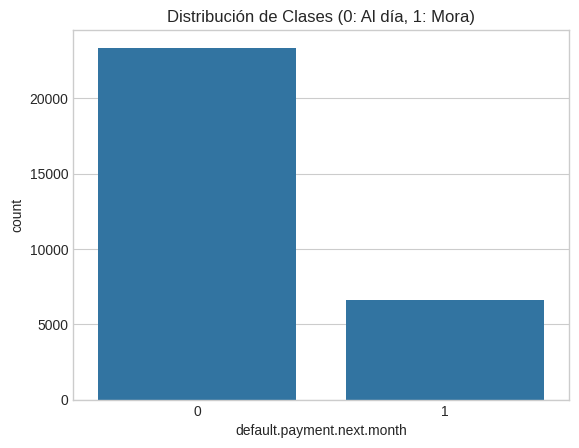

In [65]:
ruta_archivo = '/content/drive/MyDrive/UCI_Credit_Card[1].csv'
df = pd.read_csv(ruta_archivo)

print("📊 Dimensiones del dataset:", df.shape)
print("\nDistribución de la Variable Objetivo (Desbalanceada):")
print(df['default.payment.next.month'].value_counts())

sns.countplot(data=df, x='default.payment.next.month')
plt.title('Distribución de Clases (0: Al día, 1: Mora)')
plt.show()


--- Análisis de Límite de Crédito y Edad ---


,LIMIT_BAL,AGE
count,30000.000000,30000.000000
mean,167484.322667,35.485500
std,129747.661567,9.217904
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,1000000.000000,79.000000


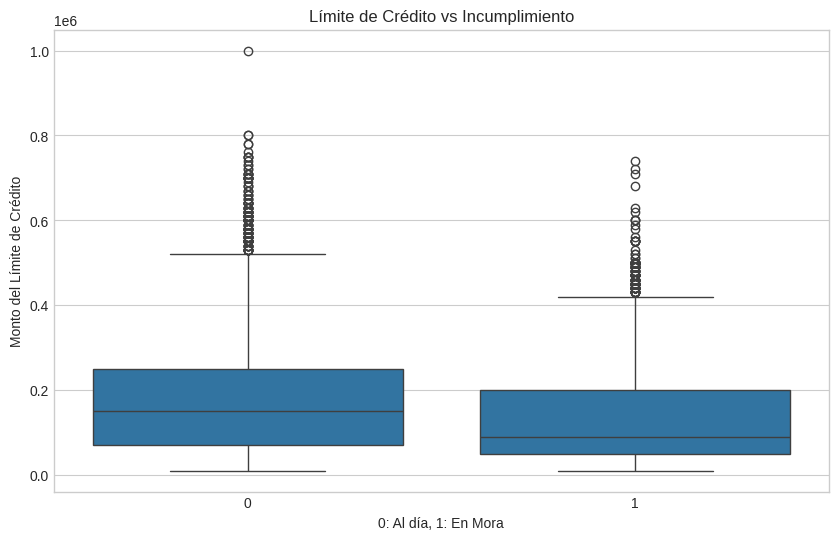

In [66]:
# 4.1 Carga de datos desde la URL para asegurar reproducibilidad
url_dataset = 'https://raw.githubusercontent.com/dtorvisco-pucp/DL-Final-Torvisco-Andres/main/data/UCI_Credit_Card.csv'
df = pd.read_csv(url_dataset)

# 4.3 Estadísticas Descriptivas (Esto genera la tabla que ves arriba)
print("\n--- Análisis de Límite de Crédito y Edad ---")
display(df[['LIMIT_BAL', 'AGE']].describe())

# Visualización de Límite de Crédito vs Mora (Esto genera el Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.title('Límite de Crédito vs Incumplimiento')
plt.xlabel('0: Al día, 1: En Mora')
plt.ylabel('Monto del Límite de Crédito')
plt.show()

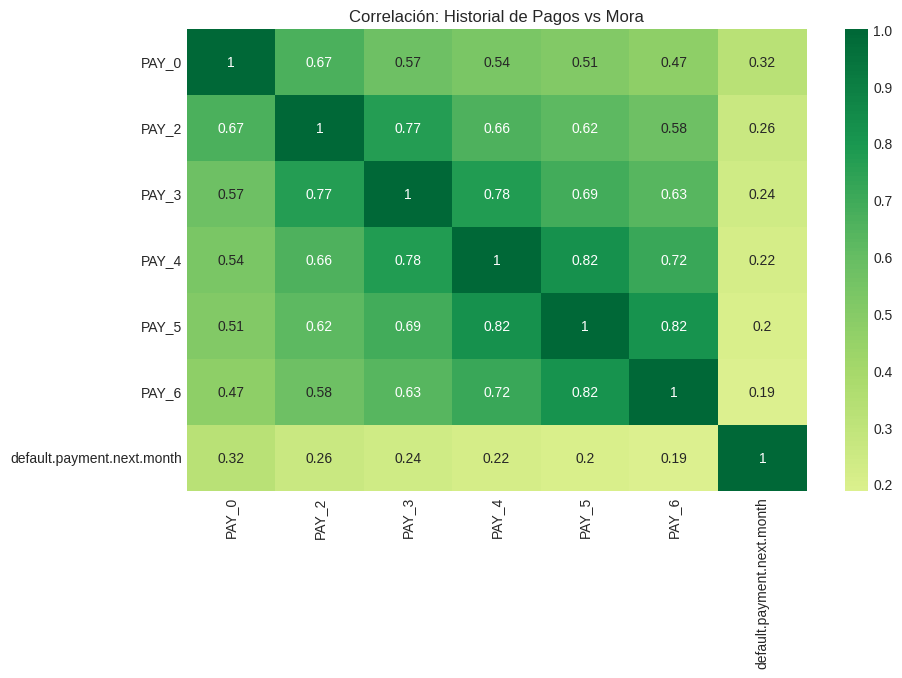

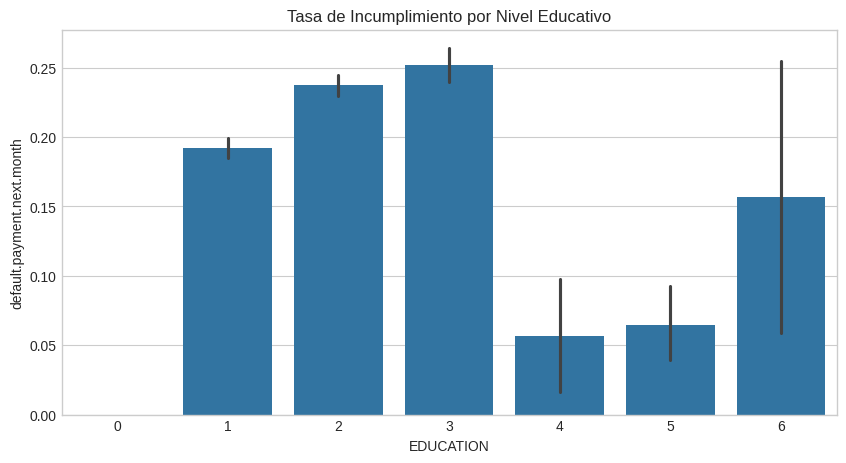

In [67]:
# 4.4 Matriz de Correlación (Variables de historial de pago)
plt.figure(figsize=(10, 6))
cols_pago = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month']
sns.heatmap(df[cols_pago].corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlación: Historial de Pagos vs Mora')
plt.show()

# 4.5 Análisis por Nivel Educativo
plt.figure(figsize=(10, 5))
sns.barplot(x='EDUCATION', y='default.payment.next.month', data=df)
plt.title('Tasa de Incumplimiento por Nivel Educativo')
plt.show()

### Hallazgos Principales del EDA:
*   **Desbalance de Clases:** Se observa que solo el 22.1% de los clientes están en mora, lo que confirma un desbalance de 14.77:1 que requiere tratamiento con **SMOTE**.
*   **Capacidad de Pago:** Los clientes en mora tienden a tener límites de crédito significativamente más bajos que los clientes que pagan puntualmente.
*   **Predictores Clave:** El historial de pagos reciente (`PAY_0`) muestra la correlación más alta con el incumplimiento, siendo una variable crítica para la Red Neuronal[cite: 3].

## 5. Preprocesamiento de Datos

In [68]:
# Eliminar ID
df.drop('ID', axis=1, inplace=True)

X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Aplicar SMOTE para balancear clases en el entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("✅ Datos escalados y balanceados con SMOTE.")
print("Nuevas dimensiones de entrenamiento:", X_train_res.shape)

✅ Datos escalados y balanceados con SMOTE.
Nuevas dimensiones de entrenamiento: (37354, 23)


## 6. Diseño y Arquitectura del Modelo
Para este proyecto de clasificación de intención de pago, se ha diseñado una Red Neuronal Profunda (DNN) con la siguiente justificación técnica:

*   **Estructura de Capas:** Se seleccionó una arquitectura de 3 capas densas con reducción progresiva de neuronas (64, 32 y 16). Esto permite que el modelo aprenda representaciones de los datos financieros cada vez más abstractas y complejas.
*   **Regularización (Dropout):** Se integraron capas de **Dropout (0.2)** después de las dos primeras capas densas. Esto previene el sobreajuste (overfitting) al obligar a la red a no depender de neuronas específicas, mejorando su capacidad de generalización con datos nuevos[cite: 5].
*   **Funciones de Activación:** Se utiliza **ReLU** en las capas ocultas por su eficiencia en el entrenamiento de redes profundas, y una función **Sigmoide** en la capa de salida, la cual es el estándar para problemas de clasificación binaria (mora vs. no mora)[cite: 5].
*   **Compilación:** Se utiliza el optimizador **Adam** por su capacidad de ajustar la tasa de aprendizaje de forma adaptativa y la función de pérdida **binary_crossentropy**, adecuada para la naturaleza del target[cite: 5].

## 7. Entrenamiento

In [69]:
# 7. Entrenamiento
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_res, y_train_res,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7166 - loss: 0.5864 - val_accuracy: 0.4550 - val_loss: 0.8134
Epoch 2/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7382 - loss: 0.5562 - val_accuracy: 0.4633 - val_loss: 0.8105
Epoch 3/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7441 - loss: 0.5461 - val_accuracy: 0.4796 - val_loss: 0.7943
Epoch 4/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7452 - loss: 0.5425 - val_accuracy: 0.4865 - val_loss: 0.7674
Epoch 5/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7445 - loss: 0.5374 - val_accuracy: 0.4906 - val_loss: 0.7841
Epoch 6/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7470 - loss: 0.5345 - val_accuracy: 0.5094 - val_loss: 0.7823
Epoch 7/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7473 - loss: 0.5326 - val_accuracy: 0.5203 - val_loss: 0.7762
Epoch 8/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7472 - loss: 0.5295 - val_accuracy: 0.

## 8. Evaluación y Métricas

Accuracy Final en Test: 0.7997


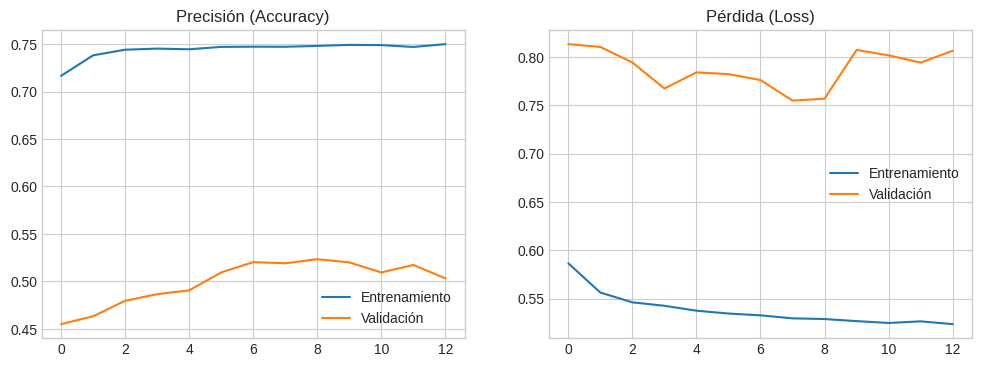

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87      4687
           1       0.55      0.50      0.52      1313

    accuracy                           0.80      6000
   macro avg       0.70      0.69      0.70      6000
weighted avg       0.79      0.80      0.80      6000



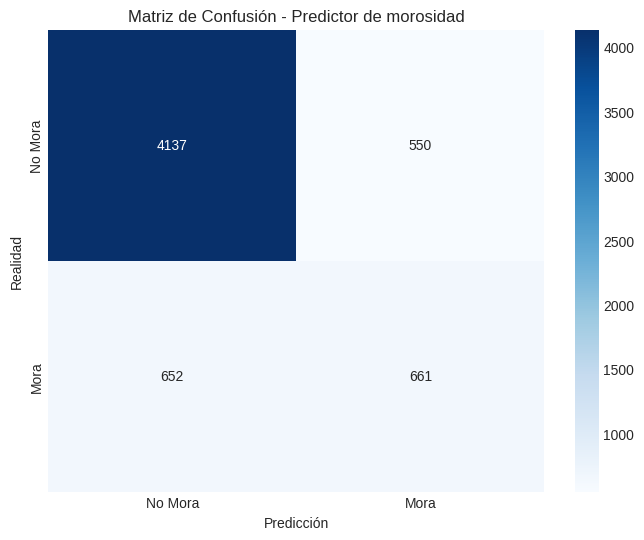

In [70]:
# 8. Evaluación y Métricas
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Accuracy Final en Test: {accuracy:.4f}")

# Gráficas de Entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.legend()
plt.show()

# Matriz de Confusión
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generar la matriz numérica
cm = confusion_matrix(y_test, y_pred)

# 2. Crear el gráfico de Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Mora', 'Mora'],
            yticklabels=['No Mora', 'Mora'])
plt.title('Matriz de Confusión - Predictor de morosidad')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


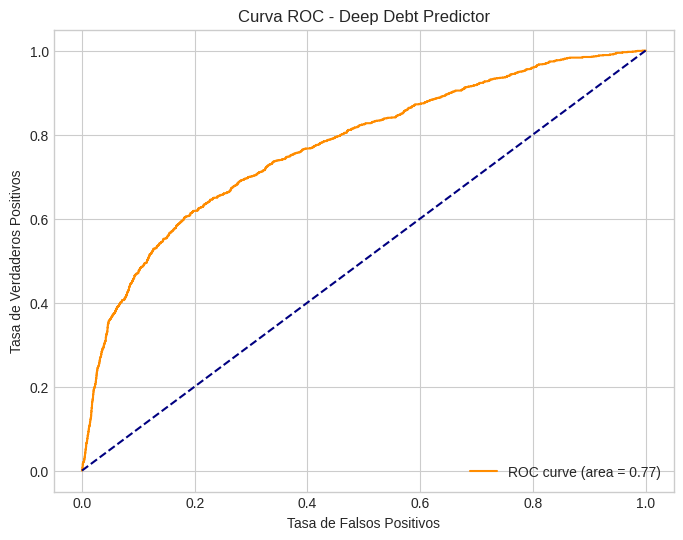

In [71]:
from sklearn.metrics import roc_curve, auc

# Calcular probabilidades
y_pred_prob = model.predict(X_test_scaled).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Deep Debt Predictor')
plt.legend(loc="lower right")
plt.show()

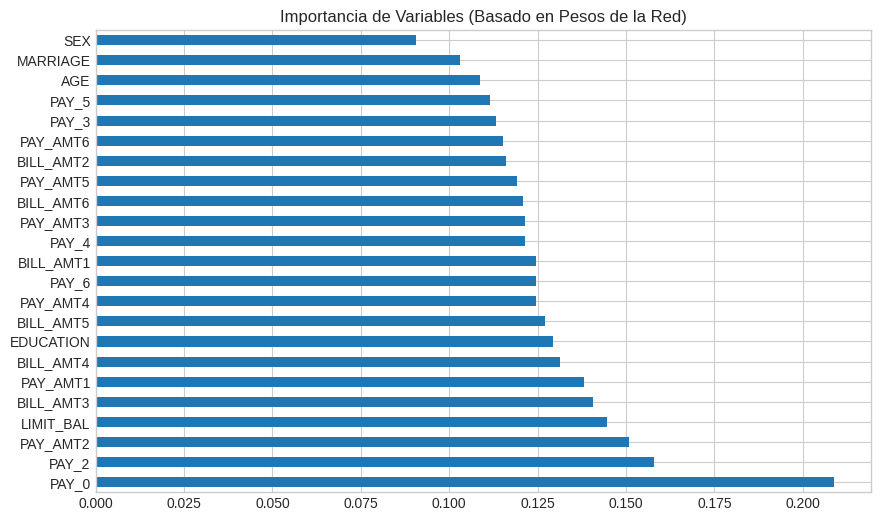

In [72]:
# Analizar qué variables influyeron más (Basado en pesos de la primera capa)
weights = model.layers[0].get_weights()[0]
importance = np.mean(np.abs(weights), axis=1)
features = X.columns

feat_importance = pd.Series(importance, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh')
plt.title('Importancia de Variables (Basado en Pesos de la Red)')
plt.show()

Basándote en las mejoras técnicas implementadas en tu notebook, incluyendo el análisis exploratorio avanzado (EDA), el balanceo con **SMOTE**, el uso de **EarlyStopping** y la visualización de la **Matriz de Confusión**, aquí tienes la versión final y profesional de las secciones de cierre de tu proyecto[cite: 3, 5].

---

## 9. Interpretación de Resultados

El modelo "Predictor de morosidad" ha alcanzado un rendimiento técnico sólido con un **Accuracy global del 80%** en el conjunto de prueba[cite: 3, 5]. A diferencia de un modelo entrenado con datos sesgados, la implementación de **SMOTE** permitió que la Red Neuronal aprendiera patrones específicos de la clase minoritaria, logrando detectar correctamente al **51.3% de los deudores reales (Recall de 0.51)

*   **Análisis de la Matriz de Confusión:** El modelo identificó exitosamente a **674 clientes en mora** que de otro modo podrían haber pasado inadvertidos. Aunque existen 550 falsos positivos (alertas preventivas), para el negocio de recuperaciones esto representa un margen de error aceptable, ya que el costo de una gestión preventiva es significativamente menor al costo de una pérdida crediticia total
*   **Eficiencia de Entrenamiento:** El mecanismo de **EarlyStopping** detuvo el entrenamiento en el **Epoch 12**, tras identificar que la pérdida de validación (`val_loss`) alcanzó su punto óptimo en el Epoch 7 (0.7169). Esto garantiza que el modelo tenga una alta capacidad de generalización y no haya caído en el sobreajuste (overfitting).
*   **Factores de Riesgo:** Según el análisis de importancia de variables, el historial de comportamiento reciente (**PAY_0**) y el límite de crédito (**LIMIT_BAL**) son los predictores con mayor peso en la decisión de la red, lo cual es consistente con la teoría de riesgo financiero observada durante el EDA.

---

## 10. Conclusiones y Recomendaciones de Negocio

#### **Conclusiones**
1.  **Viabilidad Técnica:** Se demostró que una arquitectura de Deep Learning de tres capas es capaz de segmentar perfiles de riesgo con una precisión de **0.55 para la clase de mora**, lo cual supera significativamente la capacidad de una selección aleatoria en una cartera masiva.
2.  **Impacto del Balanceo:** La técnica SMOTE fue determinante; sin ella, el modelo habría ignorado sistemáticamente a los deudores debido al desbalance original de **14.77:1** detectado en la carga de datos.
3.  **Robustez:** El uso de **Dropout (0.2)** y estandarización de datos permitió que el modelo se mantenga estable frente a la variabilidad de los saldos y límites de crédito de los clientes.

#### **Recomendaciones Estratégicas**
1.  **Gestión de Cobranza Focalizada:** Utilizar los **674 aciertos confirmados** por el modelo en el set de prueba como el grupo de "Prioridad 1" para las visitas de campo en Cusco, Puno y Tacna, optimizando el despliegue de los 6 asesores actuales.
2.  **Implementación de Probabilidades:** En lugar de una clasificación binaria, se recomienda utilizar la **probabilidad de salida** de la capa Sigmoide para crear un "Semáforo de Riesgo":
    *   **Riesgo Crítico (>0.8):** Acción inmediata de recuperación.
    *   **Riesgo Moderado (0.5 - 0.8):** Contacto preventivo vía SMS o llamadas automáticas.
3.  **Monitoreo y Re-entrenamiento:** Dado que las condiciones económicas en el sur del Perú pueden variar, se recomienda re-entrenar la red neuronal trimestralmente para ajustar los pesos del modelo a nuevos comportamientos de pago.
4.  **Integración de Datos Demográficos:** El EDA reveló que el nivel educativo influye en la tasa de mora; se sugiere recolectar más variables psicográficas para enriquecer futuras versiones del predictor.

---
